### Gráficos de dispersión

Sirve para analizar posibles relaciónes entre pares de Series de Tiempo

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clima = pd.read_csv('datos/vars_clima.csv',
                    parse_dates=['fecha'],
                    index_col='fecha')
clima # Frecuencia de muestreo de 1 hora.

,p (mbar),T (degC),Tdew (degC),rh (%),wd (deg)
fecha,,,,,
2014-01-01 00:00:00,987.18,-0.07,-4.34,72.80,190.5
2014-01-01 01:00:00,986.81,1.18,-4.53,65.55,173.7
2014-01-01 02:00:00,986.44,1.56,-4.51,63.87,192.7
2014-01-01 03:00:00,986.15,2.10,-4.35,62.19,208.0
2014-01-01 04:00:00,986.26,2.94,-4.66,57.22,224.4
...,...,...,...,...,...
2014-09-24 12:00:00,987.01,13.69,6.29,60.85,174.1
2014-09-24 13:00:00,986.55,14.19,6.80,61.01,173.0
2014-09-24 14:00:00,986.21,14.99,6.70,57.54,202.5


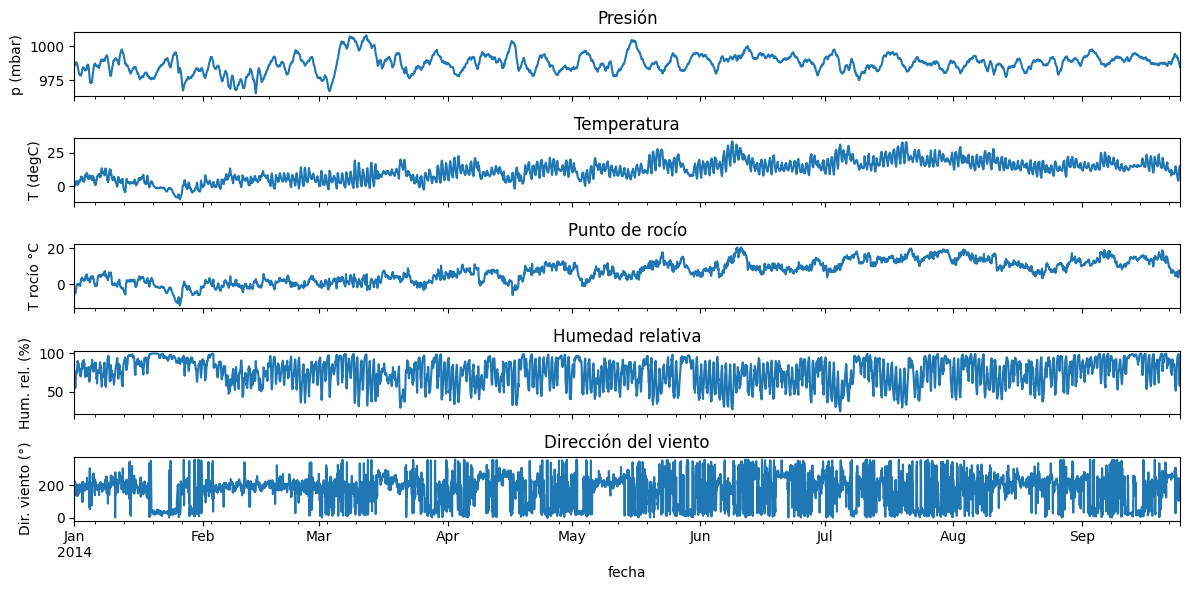

In [18]:
fig, ax = plt.subplots(5, 1, figsize=(12, 6), sharex=True)

clima['p (mbar)'].plot(ax = ax[0])
clima['T (degC)'].plot(ax = ax[1])
clima['Tdew (degC)'].plot(ax = ax[2])
clima['rh (%)'].plot(ax = ax[3])
clima['wd (deg)'].plot(ax = ax[4])

ax[0].set_ylabel('p (mbar)')
ax[0].set_title('Presión')

ax[1].set_ylabel('T (degC)')
ax[1].set_title('Temperatura')

ax[2].set_ylabel('T rocío °C')
ax[2].set_title('Punto de rocío')

ax[3].set_ylabel('Hum. rel. (%)')
ax[3].set_title('Humedad relativa')

ax[4].set_ylabel('Dir. viento (°)')
ax[4].set_title('Dirección del viento')

fig.tight_layout()

### Gráficos de dispersión basicos y cálculo de correlación

-0.049763358974157824


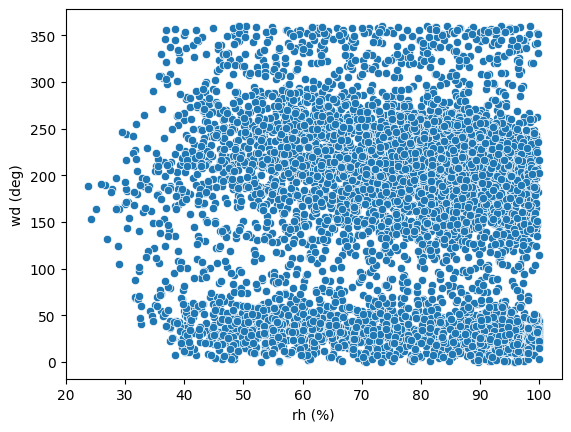

In [23]:
ax = sns.scatterplot(data = clima,
                    x = 'rh (%)',
                    y = 'wd (deg)')

corr_idx = clima['rh (%)'].corr(clima['wd (deg)'])
print(corr_idx)

### Matriz de dispersión

array([[<Axes: xlabel='p (mbar)', ylabel='p (mbar)'>,
        <Axes: xlabel='T (degC)', ylabel='p (mbar)'>,
        <Axes: xlabel='Tdew (degC)', ylabel='p (mbar)'>,
        <Axes: xlabel='rh (%)', ylabel='p (mbar)'>,
        <Axes: xlabel='wd (deg)', ylabel='p (mbar)'>],
       [<Axes: xlabel='p (mbar)', ylabel='T (degC)'>,
        <Axes: xlabel='T (degC)', ylabel='T (degC)'>,
        <Axes: xlabel='Tdew (degC)', ylabel='T (degC)'>,
        <Axes: xlabel='rh (%)', ylabel='T (degC)'>,
        <Axes: xlabel='wd (deg)', ylabel='T (degC)'>],
       [<Axes: xlabel='p (mbar)', ylabel='Tdew (degC)'>,
        <Axes: xlabel='T (degC)', ylabel='Tdew (degC)'>,
        <Axes: xlabel='Tdew (degC)', ylabel='Tdew (degC)'>,
        <Axes: xlabel='rh (%)', ylabel='Tdew (degC)'>,
        <Axes: xlabel='wd (deg)', ylabel='Tdew (degC)'>],
       [<Axes: xlabel='p (mbar)', ylabel='rh (%)'>,
        <Axes: xlabel='T (degC)', ylabel='rh (%)'>,
        <Axes: xlabel='Tdew (degC)', ylabel='rh (%)'>,
        <A

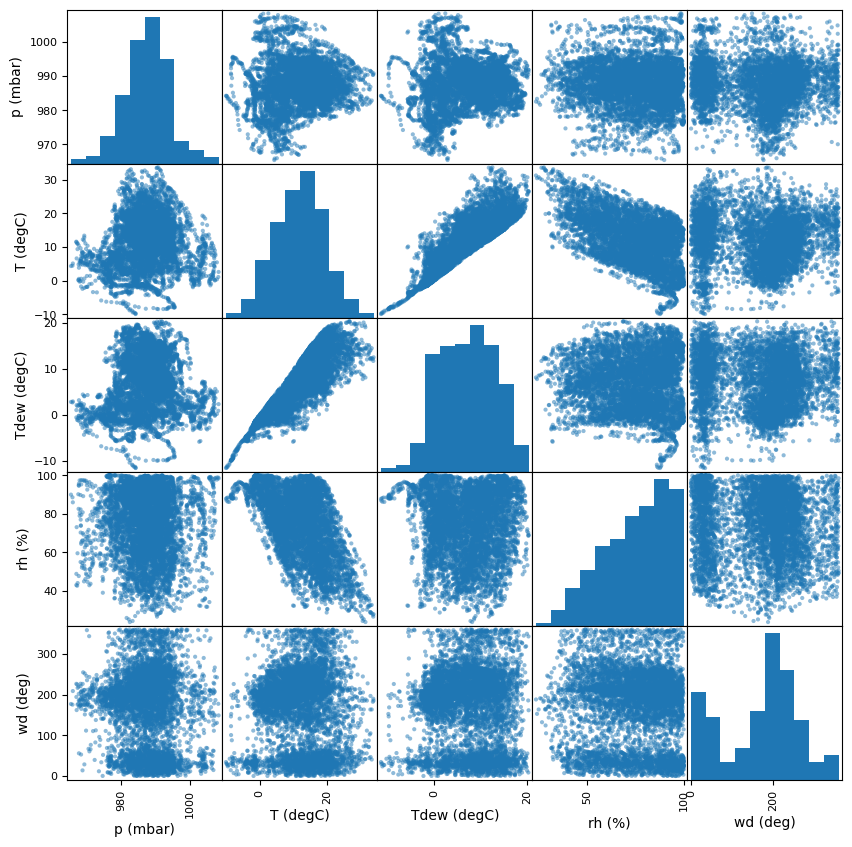

In [25]:
pd.plotting.scatter_matrix(clima, figsize=(10,10))

In [26]:
clima.corr()

,p (mbar),T (degC),Tdew (degC),rh (%),wd (deg)
p (mbar),1.000000,0.103193,0.091369,-0.044718,-0.078561
T (degC),0.103193,1.000000,0.843078,-0.536585,-0.021086
Tdew (degC),0.091369,0.843078,1.000000,-0.008154,-0.042084
rh (%),-0.044718,-0.536585,-0.008154,1.000000,-0.049763
wd (deg),-0.078561,-0.021086,-0.042084,-0.049763,1.000000


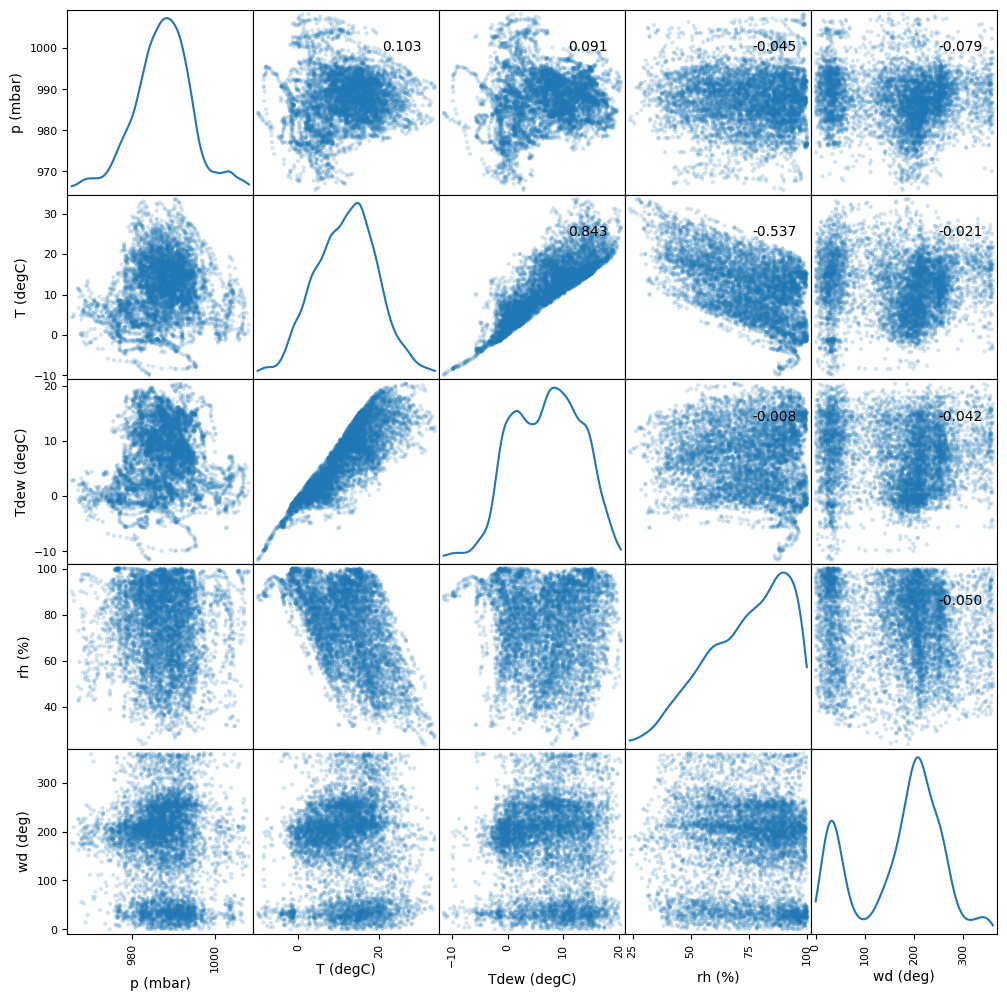

In [28]:
ax = pd.plotting.scatter_matrix(clima,
                                alpha=0.2,
                                diagonal='kde',
                                figsize=(12, 12))
corr = clima.corr().to_numpy()

for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
    ax[i, j].annotate(f'{corr[i, j]:.3f}', (0.8, 0.8),
                        xycoords = 'axes fraction',
                        ha = 'center',
                        va = 'center')
